In [2]:
# packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# read the original data
children = pd.read_csv('child24.csv')


In [4]:
# DEMOGRAPHICS

demographics = ["SEX_C", "RELTIVP_C", "RACEALLP_C"]

# MAIN OUTCOME
main_outcome = ["PHSTAT_C"]

# PSYCHOSOCIAL COVARIATES
psychosocial_covariates = ["ANXFREQ_C", "DEPFREQ_C", "SCHDYMSSTC_C"]

# SOCIAL DETERMINANTS OF HEALTH COVARIATES

# Income, Insurance

social_determinants = ["NOTCOV_C", "COVER_C", "FSNAP12M_C", "FWIC12M_C", "FLUNCH12M1_C"]

# Education
education = ["MAXPAREDUP_C"]

# Food Security

# FDSCAT34_C
food_security = ["FDSCAT3_C", "FDSCAT4_C"]

# Housing
housing = ["HOUTENURE_C"]

# Built Environment
built_environment = ["SIDEWALK_C", "PARKS_C", "TRAFFIC_C", "CRIME_C"]

# ELIGIBILITY
eligibility = ["AGEP_C", "CURFOOD_C"]

# Variables
variables = [
    *demographics,
    *main_outcome,
    *psychosocial_covariates,
    *social_determinants,
    *education,
    *food_security,
    *housing,
    *built_environment,
    *eligibility
]


child_data = children[variables]

In [5]:
# Limit the age range

children_with_age_range = child_data[
    child_data["AGEP_C"].between(5, 17)
]

# children_with_age_range

## Exploratory Data Analysis (EDA)   

### Sample Overview

- Total number of surveyed children
- The number of surveyed children in selected age range 5 to 17

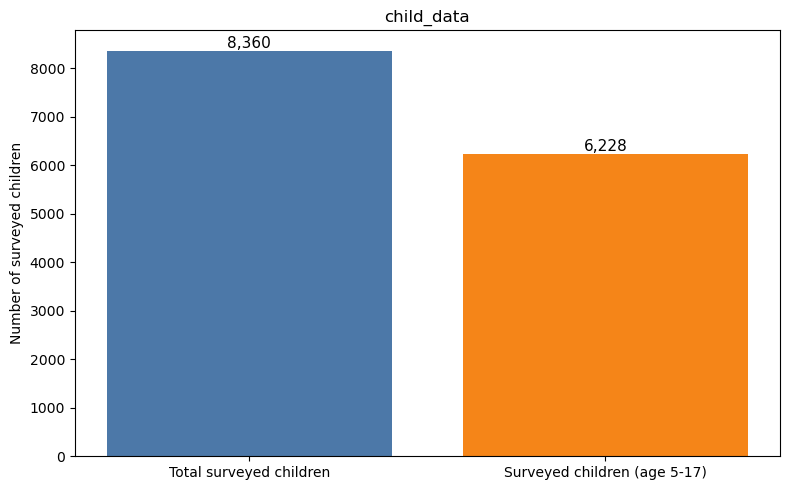

In [6]:
# Sample Overview

total_children = child_data.shape[0]
children_5_to_17 = children_with_age_range.shape[0]

sample_overview = pd.DataFrame({
    "Group": ["Total surveyed children", "Surveyed children (age 5-17)"],
    "Count": [total_children, children_5_to_17]
})

plt.figure(figsize=(8, 5))
bars = plt.bar(sample_overview["Group"], sample_overview["Count"], color=["#4C78A8", "#F58518"])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title("child_data")
plt.ylabel("Number of surveyed children")
plt.xlabel("")
plt.tight_layout()
plt.show()


### Demographics

- The number of children by age
- The number of children by sex
- The number of children by race/ethnicity

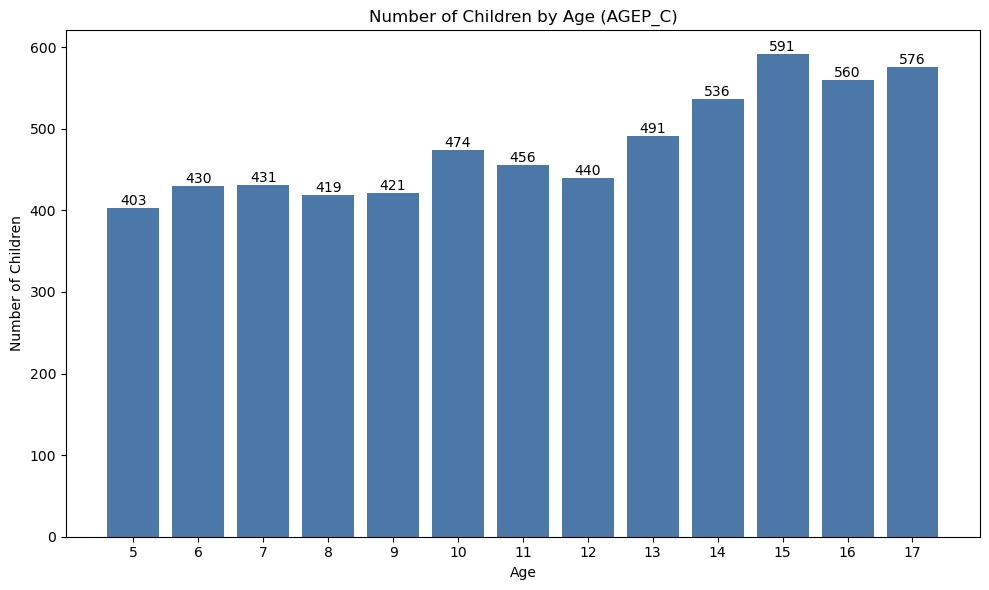

In [7]:
# Demographics - Bar chart 1: Number of children by age (5 to 17)

age_series = pd.to_numeric(child_data["AGEP_C"], errors="coerce")
age_5_to_17 = age_series[age_series.between(5, 17)]

# Keep all ages from 5 to 17 on the x-axis, filling missing ages with 0
age_counts = age_5_to_17.value_counts().reindex(range(5, 18), fill_value=0)

plt.figure(figsize=(10, 6))
bars = plt.bar(age_counts.index.astype(str), age_counts.values, color="#4C78A8")

# Show exact counts above each bar
for bar, value in zip(bars, age_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Number of Children by Age (AGEP_C)")
plt.xlabel("Age")
plt.ylabel("Number of Children")
plt.tight_layout()
plt.show()


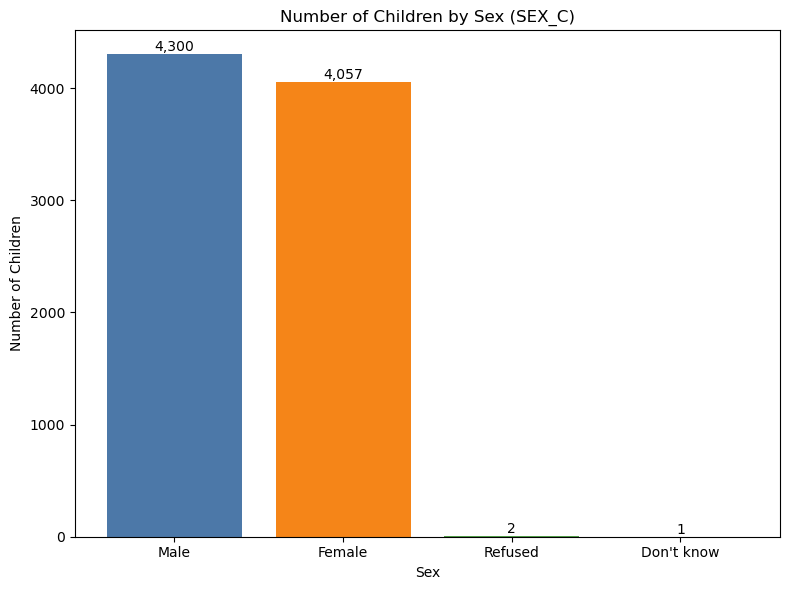

In [8]:
#| hide_input
# Demographics - Bar chart 2: Number of children by sex

sex_labels_map = {
    1: "Male",
    2: "Female",
    7: "Refused",
    8: "Not Ascertained",
    9: "Don't know"
}

sex_series = pd.to_numeric(child_data["SEX_C"], errors="coerce")
sex_counts = sex_series.value_counts().sort_index()
sex_labels = [sex_labels_map.get(int(code), f"Code {int(code)}") for code in sex_counts.index]

# Use a different color for each bar
bar_colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2"][:len(sex_counts)]

plt.figure(figsize=(8, 6))
bars = plt.bar(sex_labels, sex_counts.values, color=bar_colors)

# Show exact counts above each bar
for bar, value in zip(bars, sex_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Number of Children by Sex (SEX_C)")
plt.xlabel("Sex")
plt.ylabel("Number of Children")
plt.tight_layout()
plt.show()


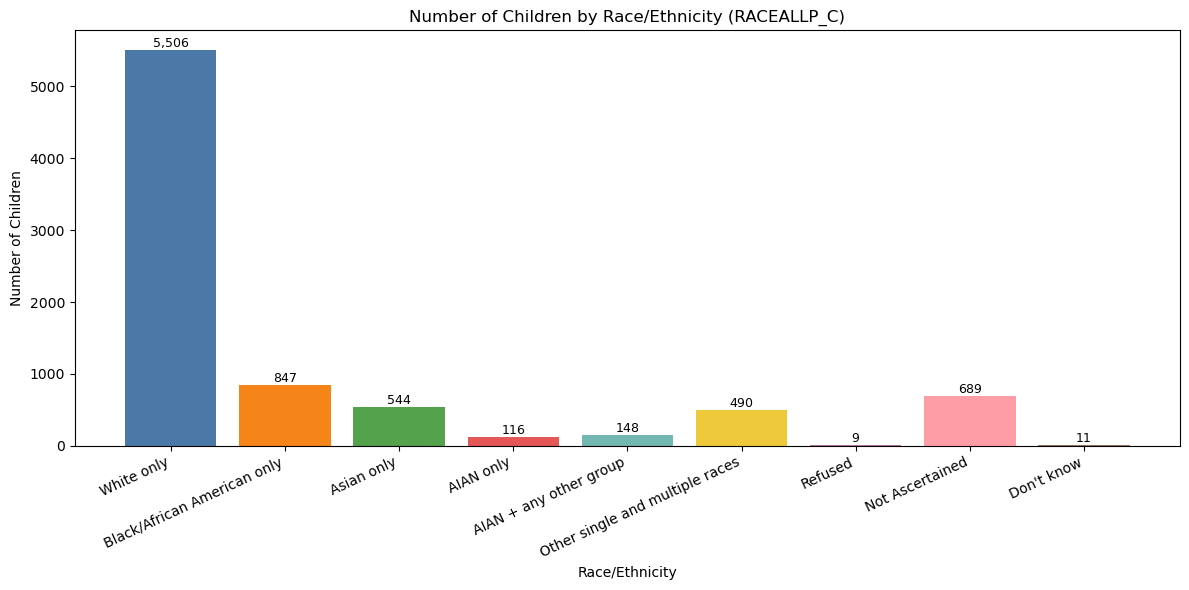

In [9]:
# Demographics - Bar chart 3: Number of children by race/ethnicity

race_labels_map = {
    1: "White only",
    2: "Black/African American only",
    3: "Asian only",
    4: "AIAN only",
    5: "AIAN + any other group",
    6: "Other single and multiple races",
    7: "Refused",
    8: "Not Ascertained",
    9: "Don't know"
}

race_series = pd.to_numeric(child_data["RACEALLP_C"], errors="coerce")
race_counts = race_series.value_counts().sort_index()
race_labels = [race_labels_map.get(int(code), f"Code {int(code)}") for code in race_counts.index]

# Use a different color for each bar
bar_colors = [
    "#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2",
    "#EECA3B", "#B279A2", "#FF9DA6", "#9D755D"
][:len(race_counts)]

plt.figure(figsize=(12, 6))
bars = plt.bar(race_labels, race_counts.values, color=bar_colors)

# Show exact counts above each bar
for bar, value in zip(bars, race_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Number of Children by Race/Ethnicity (RACEALLP_C)")
plt.xlabel("Race/Ethnicity")
plt.ylabel("Number of Children")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


### Food Allergy

- The number of children with current food allergy (CURFOOD_C)
- Percentage of children with current food allergy

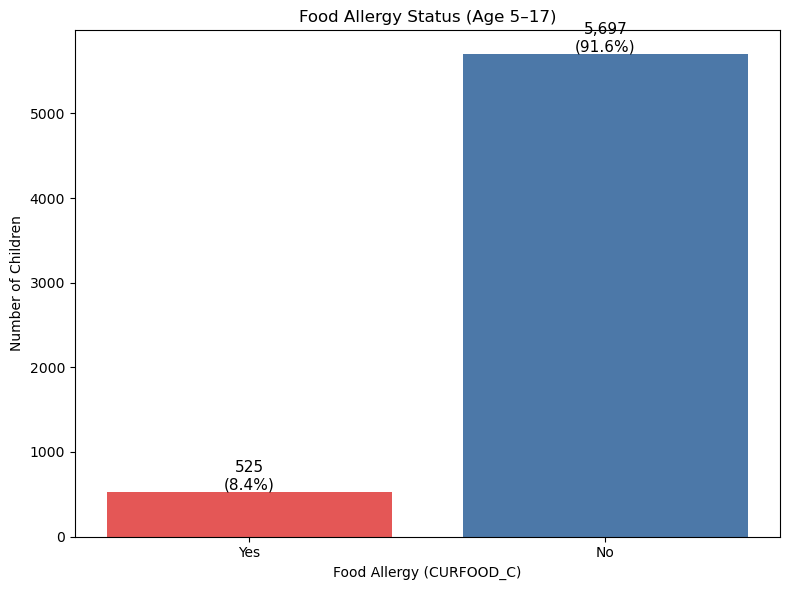

In [10]:
food_series = pd.to_numeric(
    children_with_age_range["CURFOOD_C"], errors="coerce"
)
food_series = food_series[food_series.isin([1, 2])]

# count
counts = food_series.value_counts().reindex([1, 2], fill_value=0)

# percentage
percentages = (counts / counts.sum()) * 100

# labels & colors
labels = ["Yes", "No"]
colors = ["#E45756", "#4C78A8"]

# graph
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, counts.values, color=colors)

# count + percentage
for bar, count, pct in zip(bars, counts.values, percentages.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(count):,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title("Food Allergy Status (Age 5–17)")
plt.xlabel("Food Allergy (CURFOOD_C)")
plt.ylabel("Number of Children")
plt.tight_layout()
plt.show()

- The number of children having food allergy by sex
- The number of children having food allergy by age
- The number of children having food allergy by race/ethnicity

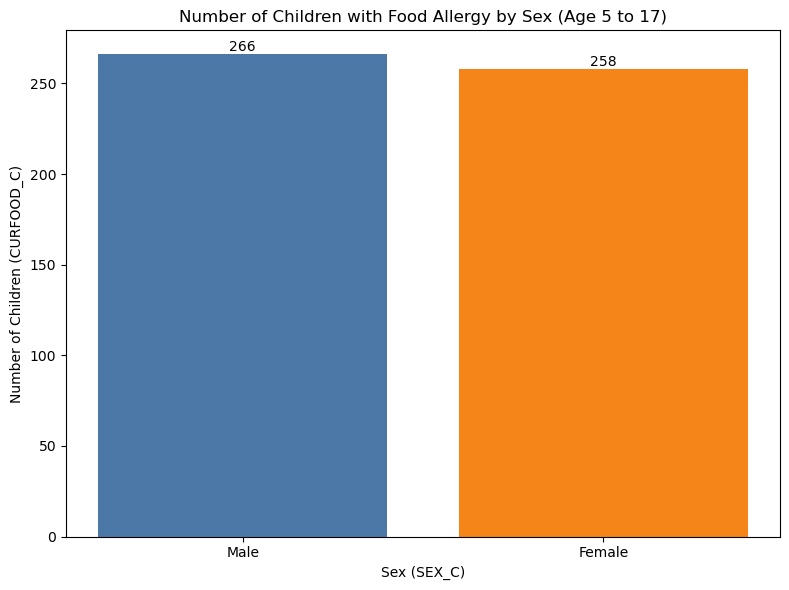

In [11]:
#| hide_input
# The number of children having food allergy by sex (Male/Female only, age 5-17)

# Keep only children with current food allergy = Yes (1)
allergy_yes = children_with_age_range[ 
    pd.to_numeric(children_with_age_range["CURFOOD_C"], errors="coerce") == 1
].copy()

# Keep only Male(1), Female(2)
sex_series = pd.to_numeric(allergy_yes["SEX_C"], errors="coerce")
sex_series = sex_series[sex_series.isin([1, 2])]

# Fixed order: Male, Female
sex_counts = sex_series.value_counts().reindex([1, 2], fill_value=0)
sex_labels = ["Male", "Female"]
bar_colors = ["#4C78A8", "#F58518"]

plt.figure(figsize=(8, 6))
bars = plt.bar(sex_labels, sex_counts.values, color=bar_colors)

# Show exact counts on bars
for bar, value in zip(bars, sex_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Number of Children with Food Allergy by Sex (Age 5 to 17)")
plt.xlabel("Sex (SEX_C)")
plt.ylabel("Number of Children (CURFOOD_C)")
plt.tight_layout()
plt.show()


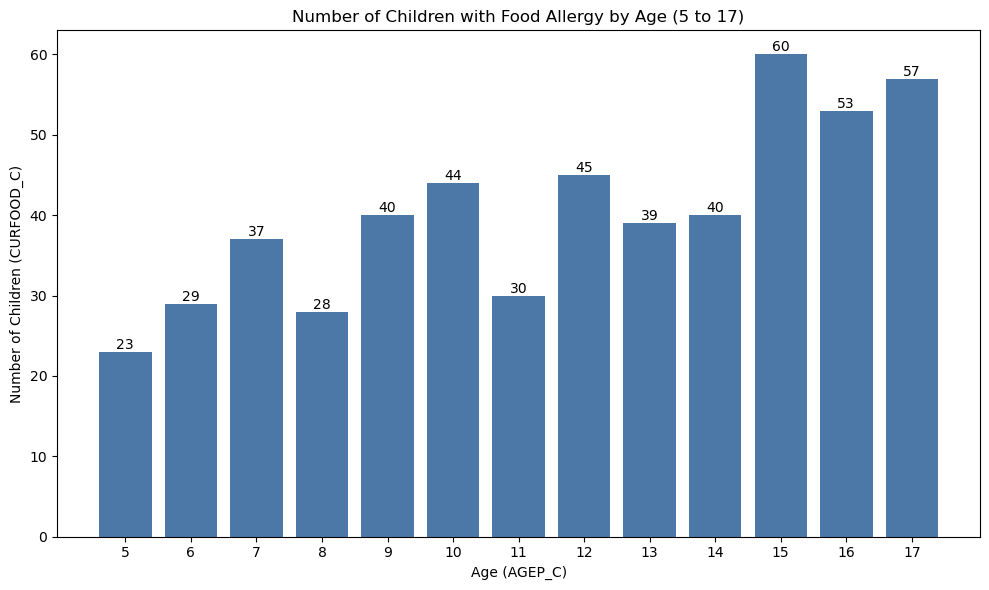

In [12]:
# The number of children having food allergy by age (5 to 17)

# Keep only children with current food allergy = Yes (1)
allergy_yes = children_with_age_range[
    pd.to_numeric(children_with_age_range["CURFOOD_C"], errors="coerce") == 1
].copy()

# Keep valid ages 5-17
age_series = pd.to_numeric(allergy_yes["AGEP_C"], errors="coerce")
age_series = age_series[age_series.between(5, 17)]

# Fixed age order 5~17, fill missing ages with 0
age_counts = age_series.value_counts().reindex(range(5, 18), fill_value=0)

plt.figure(figsize=(10, 6))
bars = plt.bar(age_counts.index.astype(str), age_counts.values, color="#4C78A8")

# Show exact counts on bars
for bar, value in zip(bars, age_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Number of Children with Food Allergy by Age (5 to 17)")
plt.xlabel("Age (AGEP_C)")
plt.ylabel("Number of Children (CURFOOD_C)")
plt.tight_layout()
plt.show()

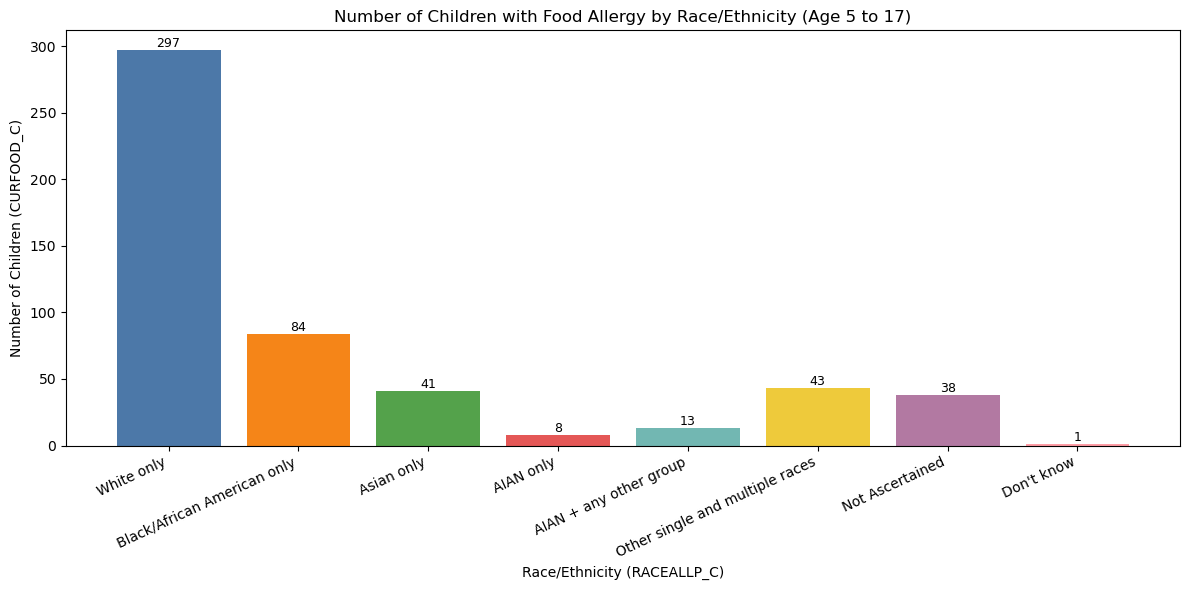

In [13]:
# The number of children having food allergy by race/ethnicity (age 5 to 17)

race_labels_map = {
    1: "White only",
    2: "Black/African American only",
    3: "Asian only",
    4: "AIAN only",
    5: "AIAN + any other group",
    6: "Other single and multiple races",
    7: "Refused",
    8: "Not Ascertained",
    9: "Don't know"
}

# Keep only children with current food allergy = Yes (1)
allergy_yes = children_with_age_range[
    pd.to_numeric(children_with_age_range["CURFOOD_C"], errors="coerce") == 1
].copy()

# Count by race/ethnicity
race_series = pd.to_numeric(allergy_yes["RACEALLP_C"], errors="coerce")
race_counts = race_series.value_counts().sort_index()
race_labels = [race_labels_map.get(int(code), f"Code {int(code)}") for code in race_counts.index]

bar_colors = [
    "#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2",
    "#EECA3B", "#B279A2", "#FF9DA6", "#9D755D"
][:len(race_counts)]

plt.figure(figsize=(12, 6))
bars = plt.bar(race_labels, race_counts.values, color=bar_colors)

# Show exact counts on bars
for bar, value in zip(bars, race_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Number of Children with Food Allergy by Race/Ethnicity (Age 5 to 17)")
plt.xlabel("Race/Ethnicity (RACEALLP_C)")
plt.ylabel("Number of Children (CURFOOD_C)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


# Analysis

What factors are associated with health status among children with food allergies?  
How does this differ when compared to children without food allergies?

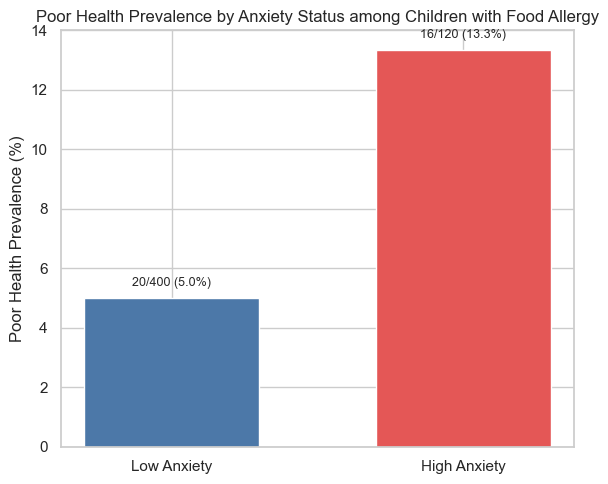

poor_health,Not Poor Health,Poor Health
high_anxiety,,
Low Anxiety,380,20
High Anxiety,104,16


chi2 = 8.6968, p-value = 0.00318776, dof = 1


In [14]:
from scipy.stats import chi2_contingency

# -----------------------------------
# 1) Data preprocessing
# -----------------------------------
df = child_data.copy()

# Age filter: 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# CURFOOD_C: 1=Allergy, 2=No Allergy, others=NaN
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# Limit to children with food allergy only
df = df[df["food_allergy"] == 1].copy()

# ANXFREQ_C: 1,2 -> 1 (High Anxiety), 3,4,5 -> 0, others -> NaN
anx = pd.to_numeric(df["ANXFREQ_C"], errors="coerce")
df["high_anxiety"] = np.where(
    anx.isin([1, 2]), 1,
    np.where(anx.isin([3, 4, 5]), 0, np.nan)
)

# PHSTAT_C: 4 -> 1 (Poor Health), 1,2,3 -> 0, others -> NaN
ph = pd.to_numeric(df["PHSTAT_C"], errors="coerce")
df["poor_health"] = np.where(
    ph == 4, 1,
    np.where(ph.isin([1, 2, 3]), 0, np.nan)
)

# -----------------------------------
# 2) Analysis
# -----------------------------------
sub = df.dropna(subset=["high_anxiety", "poor_health"]).copy()
sub["high_anxiety"] = sub["high_anxiety"].astype(int)
sub["poor_health"] = sub["poor_health"].astype(int)

ct = pd.crosstab(sub["high_anxiety"], sub["poor_health"]).reindex(
    index=[0, 1], columns=[0, 1], fill_value=0
)

poor_counts = ct[1]
totals = ct.sum(axis=1)
poor_pct = poor_counts / totals * 100

# -----------------------------------
# 3) Visualization
# -----------------------------------
sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 5))
x_labels = ["Low Anxiety", "High Anxiety"]
y_vals = [poor_pct.loc[0], poor_pct.loc[1]]
bars = plt.bar(x_labels, y_vals, color=["#4C78A8", "#E45756"], width=0.6)

for i, grp in enumerate([0, 1]):
    cnt = int(poor_counts.loc[grp])
    tot = int(totals.loc[grp])
    pct = float(poor_pct.loc[grp])
    plt.text(
        bars[i].get_x() + bars[i].get_width() / 2,
        bars[i].get_height() + 0.3,
        f"{cnt:,}/{tot:,} ({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Poor Health Prevalence by Anxiety Status among Children with Food Allergy")
plt.ylabel("Poor Health Prevalence (%)")
plt.tight_layout()
plt.show()

# -----------------------------------
# 4) Chi-square
# -----------------------------------
chi2, p, dof, exp = chi2_contingency(ct)

display(
    ct.rename(
        index={0: "Low Anxiety", 1: "High Anxiety"},
        columns={0: "Not Poor Health", 1: "Poor Health"}
    )
)

print(f"chi2 = {chi2:.4f}, p-value = {p:.6g}, dof = {dof}")


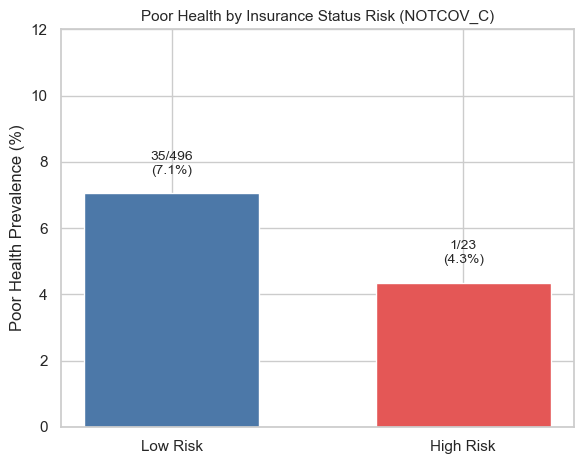

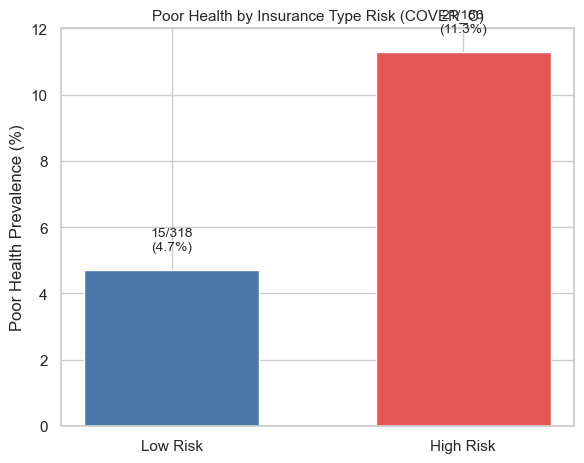

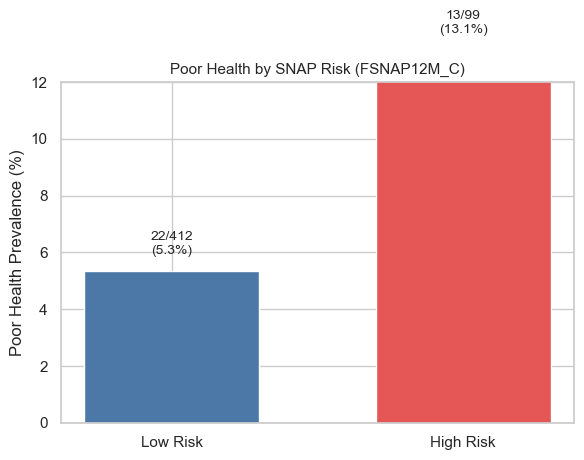

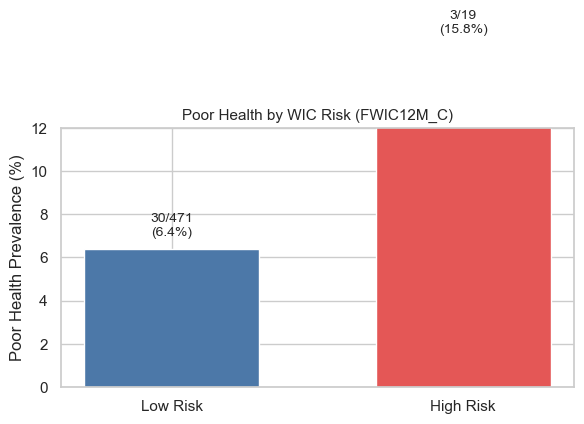

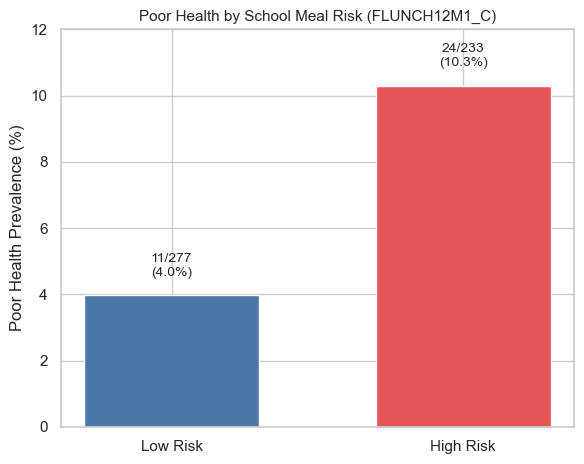

In [23]:
# -----------------------------------
# 1) Base data: age 5-17, food allergy only
# -----------------------------------
df = children_with_age_range.copy()

curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# Keep only children with food allergy
df = df[df["food_allergy"] == 1].copy()

# Poor health: 4 = poor health(1), 1/2/3 = not poor(0), others = NaN
ph = pd.to_numeric(df["PHSTAT_C"], errors="coerce")
df["poor_health"] = np.where(
    ph == 4, 1,
    np.where(ph.isin([1, 2, 3]), 0, np.nan)
)

# -----------------------------------
# 2) Recode socioeconomic variables to binary risk
# -----------------------------------
def recode_notcov(s):
    s = pd.to_numeric(s, errors="coerce")
    out = pd.Series(np.nan, index=s.index)
    out[s == 1] = 1  # uninsured = high risk
    out[s == 2] = 0  # insured = low risk
    return out

def recode_cover(s):
    s = pd.to_numeric(s, errors="coerce")
    out = pd.Series(np.nan, index=s.index)
    out[s == 1] = 0
    out[s.isin([2, 4])] = 1
    return out

def recode_yesno_risk(s):
    s = pd.to_numeric(s, errors="coerce")
    out = pd.Series(np.nan, index=s.index)
    out[s == 1] = 1
    out[s == 2] = 0
    return out

df["notcov_risk"] = recode_notcov(df["NOTCOV_C"])
df["cover_risk"] = recode_cover(df["COVER_C"])
df["snap_risk"] = recode_yesno_risk(df["FSNAP12M_C"])
df["wic_risk"] = recode_yesno_risk(df["FWIC12M_C"])
df["meal_risk"] = recode_yesno_risk(df["FLUNCH12M1_C"])

# -----------------------------------
# 3) Plot each variable separately
#    Compare poor health prevalence by risk group
# -----------------------------------
sns.set_theme(style="whitegrid")

plot_specs = [
    ("notcov_risk", "Poor Health by Insurance Status Risk (NOTCOV_C)"),
    ("cover_risk", "Poor Health by Insurance Type Risk (COVER_C)"),
    ("snap_risk", "Poor Health by SNAP Risk (FSNAP12M_C)"),
    ("wic_risk", "Poor Health by WIC Risk (FWIC12M_C)"),
    ("meal_risk", "Poor Health by School Meal Risk (FLUNCH12M1_C)"),
]

for col, title in plot_specs:
    sub = df.dropna(subset=["poor_health", col]).copy()
    sub["poor_health"] = sub["poor_health"].astype(int)
    sub[col] = sub[col].astype(int)

    totals = sub.groupby(col)["poor_health"].size().reindex([0, 1], fill_value=0)
    poor_counts = sub.groupby(col)["poor_health"].sum().reindex([0, 1], fill_value=0)
    pct = (poor_counts / totals.replace(0, np.nan) * 100).fillna(0)

    plt.figure(figsize=(6, 4.8))
    bars = plt.bar(
        ["Low Risk", "High Risk"],
        [pct.loc[0], pct.loc[1]],
        color=["#4C78A8", "#E45756"],
        width=0.6
    )

    for i, grp in enumerate([0, 1]):
        cnt = int(poor_counts.loc[grp])
        tot = int(totals.loc[grp])
        p = float(pct.loc[grp])
        plt.text(
            bars[i].get_x() + bars[i].get_width() / 2,
            bars[i].get_height() + 0.5,
            f"{cnt:,}/{tot:,}\n({p:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.title(title, fontsize=11)
    plt.ylabel("Poor Health Prevalence (%)")
    plt.ylim(0, 12)
    plt.tight_layout()
    plt.show()


Crosstab: Count


,education_group,No Allergy,Allergy
0,Low,1491,95
1,Medium,1422,140
2,High,2627,281


Crosstab: Row Percentage


,education_group,No Allergy (%),Allergy (%)
0,Low,94.01,5.99
1,Medium,91.04,8.96
2,High,90.34,9.66


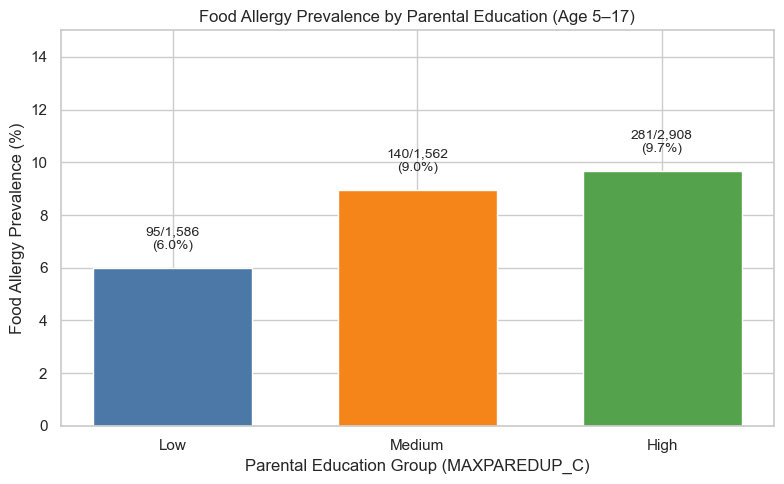

In [16]:
# -----------------------------------
# 1) Data preprocessing
# -----------------------------------
df = child_data.copy()

# (1) Age filter: 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# (2) CURFOOD_C recode: 1->1, 2->0, else NaN
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# (3) MAXPAREDUP_C recode to 3 education groups
maxedu = pd.to_numeric(df["MAXPAREDUP_C"], errors="coerce")

# Use np.select with pd.NA to avoid dtype conflict
conditions = [
    maxedu.between(0, 4),   # Low
    maxedu.between(5, 7),   # Medium
    maxedu.between(8, 10),  # High
]
choices = ["Low", "Medium", "High"]

df["education_group"] = pd.Series(
    np.select(conditions, choices, default=pd.NA),
    index=df.index,
    dtype="object"
)

# Remove missing values for analysis
analysis_df = df.dropna(subset=["education_group", "food_allergy"]).copy()
analysis_df["food_allergy"] = analysis_df["food_allergy"].astype(int)
analysis_df["education_group"] = pd.Categorical(
    analysis_df["education_group"],
    categories=["Low", "Medium", "High"],
    ordered=True
)

# -----------------------------------
# 2) Crosstab (count + row %)
# -----------------------------------
ct_count = pd.crosstab(analysis_df["education_group"], analysis_df["food_allergy"])
ct_count = ct_count.reindex(index=["Low", "Medium", "High"], columns=[0, 1], fill_value=0)
ct_count.columns = ["No Allergy", "Allergy"]

ct_pct = pd.crosstab(
    analysis_df["education_group"],
    analysis_df["food_allergy"],
    normalize="index"
) * 100
ct_pct = ct_pct.reindex(index=["Low", "Medium", "High"], columns=[0, 1], fill_value=0)
ct_pct.columns = ["No Allergy (%)", "Allergy (%)"]

ct_pct_show = ct_pct.rename_axis(None).reset_index(names="education_group")
ct_count_show = ct_count.rename_axis(None).reset_index(names="education_group")

print("Crosstab: Count")
display(ct_count_show)

print("Crosstab: Row Percentage")
display(ct_pct_show.round(2))

# -----------------------------------
# 3) Bar chart
# -----------------------------------
prev_pct = ct_pct["Allergy (%)"]
allergy_counts = ct_count["Allergy"]
group_totals = ct_count.sum(axis=1)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
bars = plt.bar(prev_pct.index, prev_pct.values, color=["#4C78A8", "#F58518", "#54A24B"], width=0.65)

for i, bar in enumerate(bars):
    grp = prev_pct.index[i]
    cnt = int(allergy_counts.loc[grp])
    tot = int(group_totals.loc[grp])
    pct = prev_pct.loc[grp]
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.6,
        f"{cnt:,}/{tot:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Food Allergy Prevalence by Parental Education (Age 5–17)")
plt.xlabel("Parental Education Group (MAXPAREDUP_C)")
plt.ylabel("Food Allergy Prevalence (%)")
plt.ylim(0, 15)
plt.tight_layout()
plt.show()


Crosstab (count):


food_insecure,High/Marginal,Low/Very Low
food_allergy,,
No Allergy,4922,682
Allergy,433,84


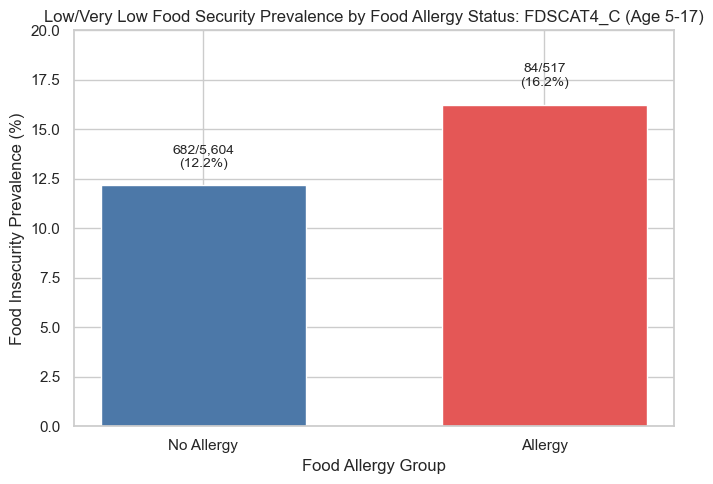

Chi-square test result
chi2 = 6.8211
p-value = 0.00900854
dof = 1


In [17]:
# -----------------------------------
# 1) Data preprocessing
# -----------------------------------
df = child_data.copy()

# (1) Age range: 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# (2) CURFOOD_C: 1=Allergy, 2=No Allergy, others=NaN
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# (3) FDSCAT4_C -> food_insecure
# 3,4 -> 1 (Low/Very Low), 1,2 -> 0 (High/Marginal), others(8,etc.) -> NaN
fd = pd.to_numeric(df["FDSCAT4_C"], errors="coerce")
df["food_insecure"] = np.where(
    fd.isin([3, 4]), 1,
    np.where(fd.isin([1, 2]), 0, np.nan)
)

# Remove missing
analysis_df = df.dropna(subset=["food_allergy", "food_insecure"]).copy()
analysis_df["food_allergy"] = analysis_df["food_allergy"].astype(int)
analysis_df["food_insecure"] = analysis_df["food_insecure"].astype(int)

# -----------------------------------
# 2) Crosstab + prevalence
# -----------------------------------
ct = pd.crosstab(analysis_df["food_allergy"], analysis_df["food_insecure"]).reindex(
    index=[0, 1], columns=[0, 1], fill_value=0
)
# index: 0 No allergy, 1 Allergy
# col 1: Low/Very Low food security count

insecure_counts = ct[1]
totals = ct.sum(axis=1)
insecure_pct = (insecure_counts / totals * 100)

# Display crosstab
ct_show = ct.rename(index={0: "No Allergy", 1: "Allergy"},
                    columns={0: "High/Marginal", 1: "Low/Very Low"})
print("Crosstab (count):")
display(ct_show)

# -----------------------------------
# 3) Visualization
# -----------------------------------
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

x_labels = ["No Allergy", "Allergy"]
y_vals = [insecure_pct.loc[0], insecure_pct.loc[1]]
bars = plt.bar(x_labels, y_vals, color=["#4C78A8", "#E45756"], width=0.6)

for i, grp in enumerate([0, 1]):
    cnt = int(insecure_counts.loc[grp])
    tot = int(totals.loc[grp])
    pct = float(insecure_pct.loc[grp])
    plt.text(
        bars[i].get_x() + bars[i].get_width() / 2,
        bars[i].get_height() + 0.8,
        f"{cnt:,}/{tot:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Low/Very Low Food Security Prevalence by Food Allergy Status: FDSCAT4_C (Age 5-17)")
plt.xlabel("Food Allergy Group")
plt.ylabel("Food Insecurity Prevalence (%)")
plt.ylim(0, 20)
plt.tight_layout()
plt.show()

# -----------------------------------
# 4) Chi-square test
# -----------------------------------
chi2, p_value, dof, expected = chi2_contingency(ct)

print("Chi-square test result")
print(f"chi2 = {chi2:.4f}")
print(f"p-value = {p_value:.6g}")
print(f"dof = {dof}")


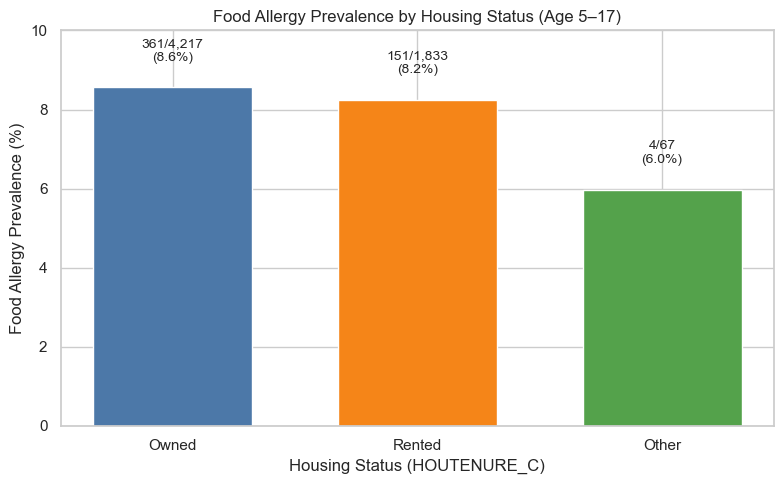

In [18]:
#| hide_input
# -----------------------------------
# 1) Data preprocessing
# -----------------------------------
df = child_data.copy()

# (1) Age filter: 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# (2) CURFOOD_C recode: 1->1, 2->0, else NaN
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# (3) HOUTENURE_C recode
house = pd.to_numeric(df["HOUTENURE_C"], errors="coerce")
housing_map = {1: "Owned", 2: "Rented", 3: "Other"}
df["housing_group"] = house.map(housing_map)  # 7,8,9 and others -> NaN

# Optional: exclude "Other" if desired
# df.loc[df["housing_group"] == "Other", "housing_group"] = np.nan

# Remove missing values
analysis_df = df.dropna(subset=["housing_group", "food_allergy"]).copy()
analysis_df["food_allergy"] = analysis_df["food_allergy"].astype(int)
analysis_df["housing_group"] = pd.Categorical(
    analysis_df["housing_group"],
    categories=["Owned", "Rented", "Other"],
    ordered=True
)

# -----------------------------------
# 2) Crosstab (count + row %)
# -----------------------------------
ct_count = pd.crosstab(analysis_df["housing_group"], analysis_df["food_allergy"])
ct_count = ct_count.reindex(index=["Owned", "Rented", "Other"], columns=[0, 1], fill_value=0)
ct_count.columns = ["No Allergy", "Allergy"]

ct_pct = pd.crosstab(
    analysis_df["housing_group"],
    analysis_df["food_allergy"],
    normalize="index"
) * 100
ct_pct = ct_pct.reindex(index=["Owned", "Rented", "Other"], columns=[0, 1], fill_value=0)
ct_pct.columns = ["No Allergy (%)", "Allergy (%)"]

# Display tables with one-line header style
# print("Crosstab: Count")
# display(ct_count.rename_axis(None).reset_index(names="housing_group"))

# print("Crosstab: Row Percentage")
# display(ct_pct.round(2).rename_axis(None).reset_index(names="housing_group"))

# -----------------------------------
# 3) Bar chart
# -----------------------------------
prev_pct = ct_pct["Allergy (%)"]
allergy_counts = ct_count["Allergy"]
group_totals = ct_count.sum(axis=1)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
bars = plt.bar(
    prev_pct.index,
    prev_pct.values,
    color=["#4C78A8", "#F58518", "#54A24B"],
    width=0.65
)

for i, bar in enumerate(bars):
    grp = prev_pct.index[i]
    cnt = int(allergy_counts.loc[grp])
    tot = int(group_totals.loc[grp])
    pct = prev_pct.loc[grp]
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.6,
        f"{cnt:,}/{tot:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Food Allergy Prevalence by Housing Status (Age 5–17)")
plt.xlabel("Housing Status (HOUTENURE_C)")
plt.ylabel("Food Allergy Prevalence (%)")
plt.ylim(0, 10)
plt.tight_layout()
plt.show()


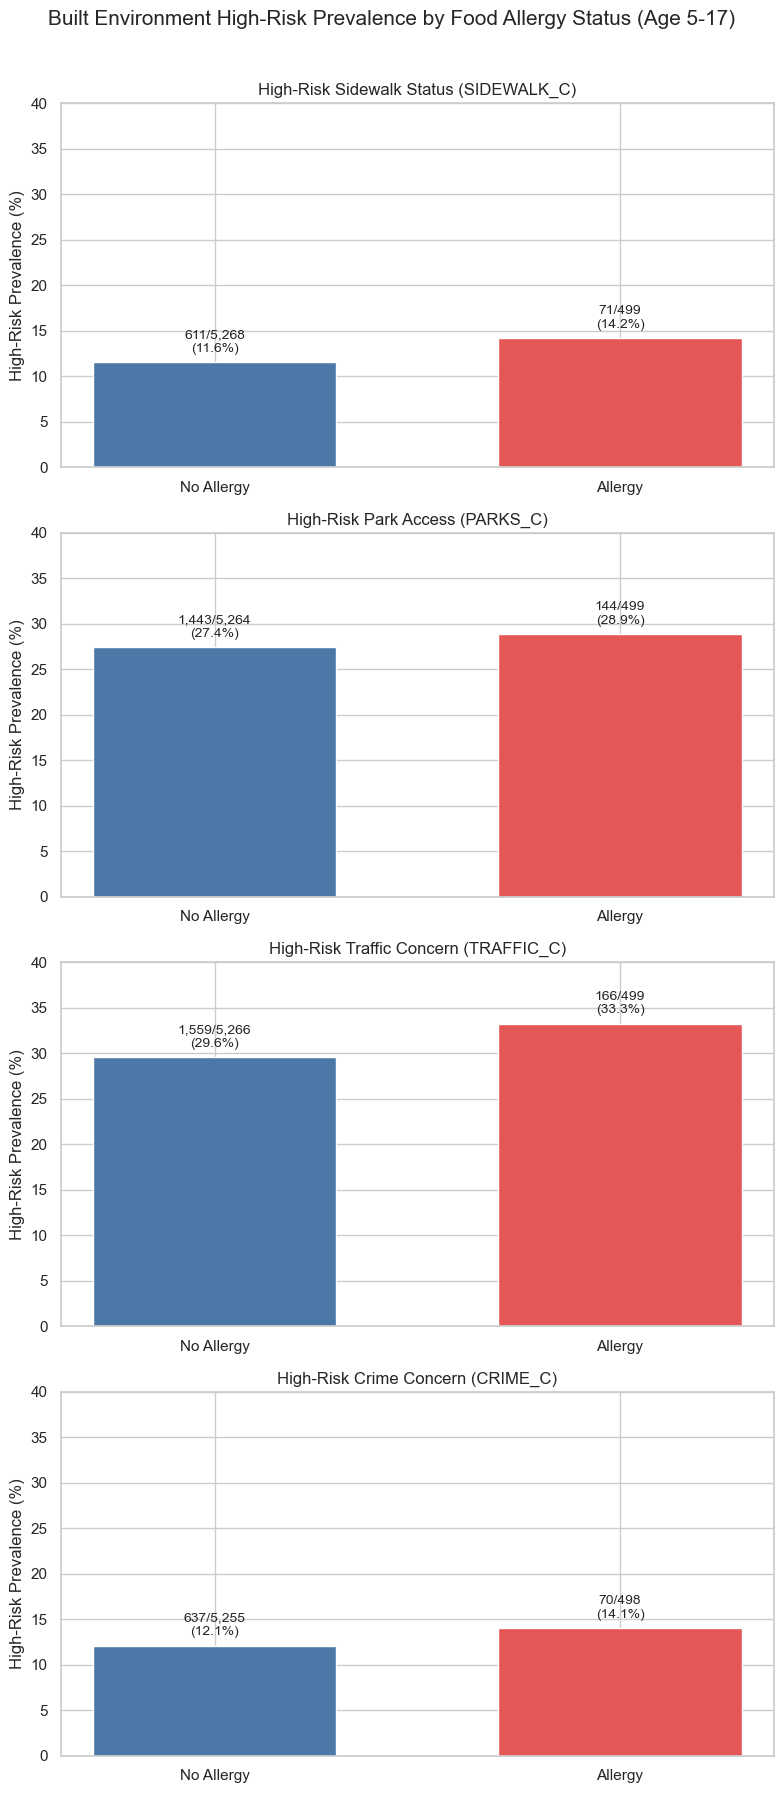

In [19]:
# -----------------------------
# 1) Filter: age 5-17 + keep both allergy groups
# -----------------------------
df = child_data.copy()

age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# -----------------------------
# 2) Recode built environment to high-risk indicators
# -----------------------------
def to_num(s):
    return pd.to_numeric(s, errors="coerce")

sidewalk = to_num(df["SIDEWALK_C"])
parks = to_num(df["PARKS_C"])
traffic = to_num(df["TRAFFIC_C"])
crime = to_num(df["CRIME_C"])

# High-risk:
# Sidewalk/Parks: No(2)=1 high-risk, Yes(1)=0
# Traffic/Crime: Yes(1)=1 high-risk, No(2)=0
df["sidewalk_high_risk"] = np.where(sidewalk == 2, 1, np.where(sidewalk == 1, 0, np.nan))
df["parks_high_risk"] = np.where(parks == 2, 1, np.where(parks == 1, 0, np.nan))
df["traffic_high_risk"] = np.where(traffic == 1, 1, np.where(traffic == 2, 0, np.nan))
df["crime_high_risk"] = np.where(crime == 1, 1, np.where(crime == 2, 0, np.nan))

# -----------------------------
# 3) 4x1 subplot (one plot per row)
# -----------------------------
sns.set_theme(style="whitegrid")

plot_specs = [
    ("sidewalk_high_risk", "High-Risk Sidewalk Status (SIDEWALK_C)"),
    ("parks_high_risk", "High-Risk Park Access (PARKS_C)"),
    ("traffic_high_risk", "High-Risk Traffic Concern (TRAFFIC_C)"),
    ("crime_high_risk", "High-Risk Crime Concern (CRIME_C)"),
]

fig, axes = plt.subplots(4, 1, figsize=(8, 18), sharey=True)

for ax, (col, title) in zip(axes, plot_specs):
    sub = df.dropna(subset=["food_allergy", col]).copy()
    sub["food_allergy"] = sub["food_allergy"].astype(int)
    sub[col] = sub[col].astype(int)

    totals = sub.groupby("food_allergy")[col].size().reindex([0, 1], fill_value=0)
    high_counts = sub.groupby("food_allergy")[col].sum().reindex([0, 1], fill_value=0)
    pcts = (high_counts / totals.replace(0, np.nan) * 100).fillna(0)

    bars = ax.bar(
        [0, 1],
        [pcts.loc[0], pcts.loc[1]],
        color=["#4C78A8", "#E45756"],
        width=0.6
    )

    for i, grp in enumerate([0, 1]):
        cnt = int(high_counts.loc[grp])
        tot = int(totals.loc[grp])
        pct = float(pcts.loc[grp])
        ax.text(
            bars[i].get_x() + bars[i].get_width() / 2,
            bars[i].get_height() + 0.8,
            f"{cnt:,}/{tot:,}\n({pct:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=10
        )

    ax.set_title(title)
    ax.set_xticks([0, 1], ["No Allergy", "Allergy"])
    ax.set_ylim(0, 40)
    ax.set_ylabel("High-Risk Prevalence (%)")

fig.suptitle("Built Environment High-Risk Prevalence by Food Allergy Status (Age 5-17)", fontsize=15, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

Poor health among children with food allergy only:
36/522 (6.90%)


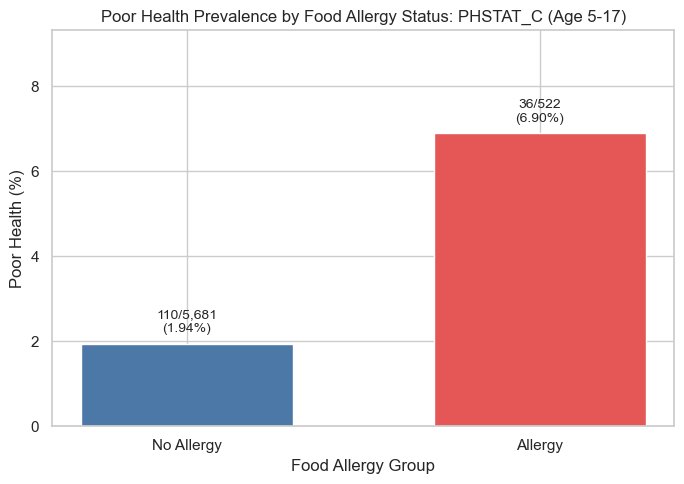


Crosstab (count):


poor_health,Not Poor,Poor
food_allergy,,
No Allergy,5571,110
Allergy,486,36


chi2 = 49.0442
p-value = 2.50256e-12
dof = 1


In [20]:
# CURFOOD_C vs. PHSTAT_C

# -----------------------------------
# 1) Data preprocessing
# -----------------------------------
df = child_data.copy()

# Age filter: 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# CURFOOD_C recode: 1=Allergy, 2=No allergy, others=NaN
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# PHSTAT_C recode: 4=Poor health(1), 1/2/3=Not poor(0), 7/8/9=NaN
ph = pd.to_numeric(df["PHSTAT_C"], errors="coerce")
df["poor_health"] = np.where(
    ph == 4, 1,
    np.where(ph.isin([1, 2, 3]), 0, np.nan)
)

# Remove missing
analysis_df = df.dropna(subset=["food_allergy", "poor_health"]).copy()
analysis_df["food_allergy"] = analysis_df["food_allergy"].astype(int)
analysis_df["poor_health"] = analysis_df["poor_health"].astype(int)

# -----------------------------------
# 2) Analysis
# -----------------------------------
# (1) Poor health prevalence among allergy group only
allergy_only = analysis_df[analysis_df["food_allergy"] == 1]
allergy_poor_rate = allergy_only["poor_health"].mean() * 100
allergy_poor_count = int(allergy_only["poor_health"].sum())
allergy_total = len(allergy_only)

print("Poor health among children with food allergy only:")
print(f"{allergy_poor_count:,}/{allergy_total:,} ({allergy_poor_rate:.2f}%)")

# (2) Compare prevalence by allergy status
ct_count = pd.crosstab(analysis_df["food_allergy"], analysis_df["poor_health"]).reindex(
    index=[0, 1], columns=[0, 1], fill_value=0
)
# index: 0 No allergy, 1 Allergy; column 1 = poor health count
poor_pct = (ct_count[1] / ct_count.sum(axis=1) * 100)
poor_pct.index = ["No Allergy", "Allergy"]

poor_counts = ct_count[1].copy()
poor_counts.index = ["No Allergy", "Allergy"]
group_totals = ct_count.sum(axis=1).copy()
group_totals.index = ["No Allergy", "Allergy"]

# -----------------------------------
# 3) Visualization
# -----------------------------------
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))
bars = plt.bar(poor_pct.index, poor_pct.values, color=["#4C78A8", "#E45756"], width=0.6)

for i, bar in enumerate(bars):
    grp = poor_pct.index[i]
    cnt = int(poor_counts.loc[grp])
    tot = int(group_totals.loc[grp])
    pct = poor_pct.loc[grp]
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{cnt:,}/{tot:,}\n({pct:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Poor Health Prevalence by Food Allergy Status: PHSTAT_C (Age 5-17)")
plt.xlabel("Food Allergy Group")
plt.ylabel("Poor Health (%)")
plt.ylim(0, max(5, poor_pct.max() * 1.35))
plt.tight_layout()
plt.show()

# -----------------------------------
# 4) Chi-square test
# -----------------------------------
chi2, p_value, dof, expected = chi2_contingency(ct_count)

print("\nCrosstab (count):")
display(ct_count.rename(index={0: "No Allergy", 1: "Allergy"},
                        columns={0: "Not Poor", 1: "Poor"}))

print(f"chi2 = {chi2:.4f}")
print(f"p-value = {p_value:.6g}")
print(f"dof = {dof}")


## Logistic Regression for Food Allergy

This section fits a multivariable logistic regression model to identify psychosocial and socioeconomic factors associated with current food allergy among children ages 5-17. Variables are dichotomized using the same logic used earlier in this notebook whenever applicable.


Excluded variables from the logistic regression:
- AGEP_C: Excluded from this modified model, as requested.
- RACEALLP_C: Excluded because it is multi-category and was not dichotomized.
- RELTIVP_C: Excluded because it is multi-category and was not dichotomized.
- FDSCAT3_C: Excluded because this notebook already uses FDSCAT4_C as the binary food security measure.

Modified model sample size: 4,959
Poor health = 1: 113
Poor health = 0: 4,846

Modified logistic regression results:


,label,beta,odds_ratio,ci_lower,ci_upper,p_value,significant
0,High Absence,2.754033,15.705845,7.025307,35.112137,1.954271e-11,True
1,Food Allergy,1.334523,3.798182,2.385241,6.048103,1.884380e-08,True
2,High Depression,0.856257,2.354332,1.282463,4.322057,5.733608e-03,True
3,High Anxiety,0.731456,2.078104,1.274595,3.388148,3.359329e-03,True
4,Low Parent Education (0-5 vs 6-10),0.635036,1.887090,1.188013,2.997534,7.152621e-03,True
5,Food Insecurity,0.471277,1.602039,0.991041,2.589730,5.445004e-02,False
6,Housing: Rented vs Owned,0.461211,1.585994,1.022010,2.461206,3.967978e-02,True
7,School Meal High Risk,0.439109,1.551324,0.965653,2.492206,6.945279e-02,False
8,Insurance Type High Risk,0.438168,1.549866,0.938716,2.558904,8.675750e-02,False
9,No Sidewalk High Risk,0.168689,1.183752,0.648647,2.160293,5.825829e-01,False



Model comparison:
- Existing model sample size: 6,203
- Modified model sample size: 4,959


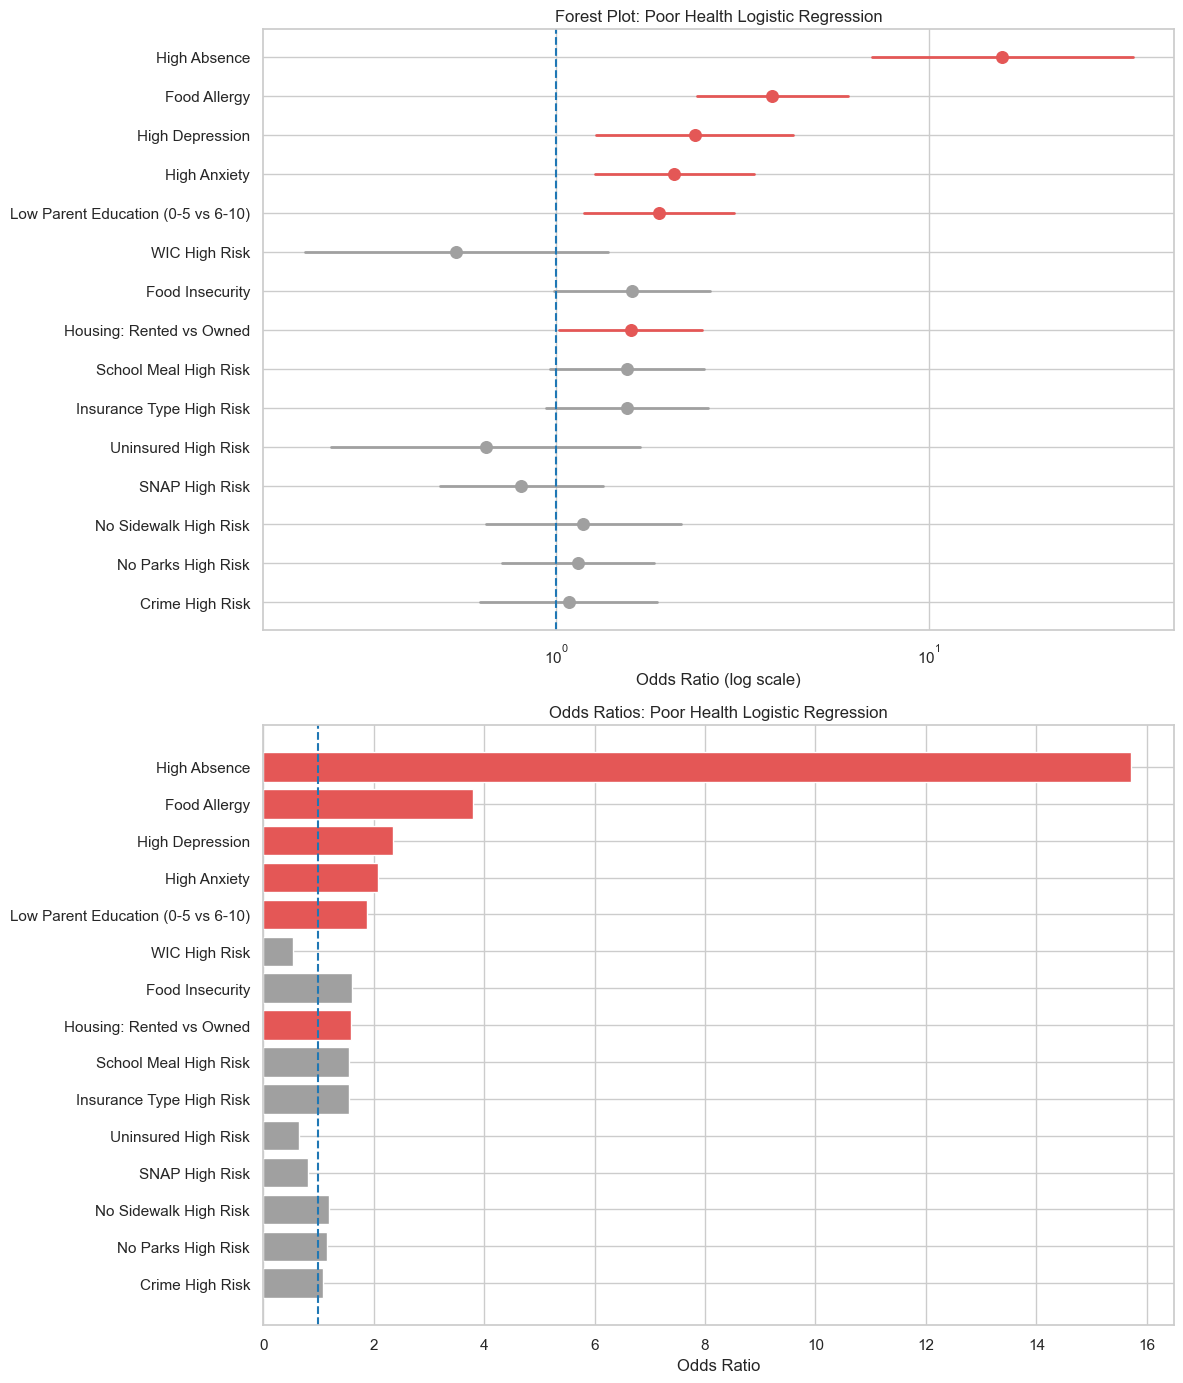

Interpretation:
- High Absence is significantly associated with poor health (OR=15.71, 95% CI 7.03-35.11, p=1.95e-11). This corresponds to 15.71 times higher odds.
- Food Allergy is significantly associated with poor health (OR=3.80, 95% CI 2.39-6.05, p=1.88e-08). This corresponds to 3.80 times higher odds.
- High Anxiety is significantly associated with poor health (OR=2.08, 95% CI 1.27-3.39, p=0.00336). This corresponds to 2.08 times higher odds.
- High Depression is significantly associated with poor health (OR=2.35, 95% CI 1.28-4.32, p=0.00573). This corresponds to 2.35 times higher odds.
- Low Parent Education (0-5 vs 6-10) is significantly associated with poor health (OR=1.89, 95% CI 1.19-3.00, p=0.00715). This corresponds to 1.89 times higher odds.
- Housing: Rented vs Owned is significantly associated with poor health (OR=1.59, 95% CI 1.02-2.46, p=0.0397). This corresponds to 1.59 times higher odds.
- In this modified model, poor health is the outcome and food allergy is a pred

In [21]:
import statsmodels.api as sm
from IPython.display import display

# =========================================================
# Modified Logistic Regression
# Outcome = poor_health
# Age removed
# =========================================================

# -----------------------------------
# 0) Variables excluded from this logistic regression
# -----------------------------------
excluded_variables = {
    "AGEP_C": "Excluded from this modified model, as requested.",
    "RACEALLP_C": "Excluded because it is multi-category and was not dichotomized.",
    "RELTIVP_C": "Excluded because it is multi-category and was not dichotomized.",
    "FDSCAT3_C": "Excluded because this notebook already uses FDSCAT4_C as the binary food security measure."
}

print("Excluded variables from the logistic regression:")
for var, reason in excluded_variables.items():
    print(f"- {var}: {reason}")

# -----------------------------------
# 1) Data preprocessing
# -----------------------------------
df = child_data.copy()

# Age filter: 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# Outcome: poor health
ph = pd.to_numeric(df["PHSTAT_C"], errors="coerce")
df["poor_health"] = np.where(
    ph == 4, 1,
    np.where(ph.isin([1, 2, 3]), 0, np.nan)
)

# Main predictor: food allergy
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# Psychosocial
anx = pd.to_numeric(df["ANXFREQ_C"], errors="coerce")
df["high_anxiety"] = np.where(
    anx.isin([1, 2]), 1,
    np.where(anx.isin([3, 4, 5]), 0, np.nan)
)

dep = pd.to_numeric(df["DEPFREQ_C"], errors="coerce")
df["high_depression"] = np.where(
    dep.isin([1, 2]), 1,
    np.where(dep.isin([3, 4, 5]), 0, np.nan)
)

sch = pd.to_numeric(df["SCHDYMSSTC_C"], errors="coerce")
df["high_absence"] = np.where(
    sch.between(40, 95), 1,
    np.where(sch.between(0, 39), 0, np.nan)
)

# SDOH / socioeconomic
notcov = pd.to_numeric(df["NOTCOV_C"], errors="coerce")
df["notcov_risk"] = np.where(notcov == 1, 1, np.where(notcov == 2, 0, np.nan))

cover = pd.to_numeric(df["COVER_C"], errors="coerce")
df["cover_risk"] = np.where(cover == 1, 0, np.where(cover.isin([2, 4]), 1, np.nan))

snap = pd.to_numeric(df["FSNAP12M_C"], errors="coerce")
df["snap_risk"] = np.where(snap == 1, 1, np.where(snap == 2, 0, np.nan))

wic = pd.to_numeric(df["FWIC12M_C"], errors="coerce")
df["wic_risk"] = np.where(wic == 1, 1, np.where(wic == 2, 0, np.nan))

meal = pd.to_numeric(df["FLUNCH12M1_C"], errors="coerce")
df["meal_risk"] = np.where(meal == 1, 1, np.where(meal == 2, 0, np.nan))

# Education: binary
maxedu = pd.to_numeric(df["MAXPAREDUP_C"], errors="coerce")
df["low_parent_education"] = np.where(
    maxedu.between(0, 5), 1,
    np.where(maxedu.between(6, 10), 0, np.nan)
)

# Food security
fd = pd.to_numeric(df["FDSCAT4_C"], errors="coerce")
df["food_insecure"] = np.where(
    fd.isin([3, 4]), 1,
    np.where(fd.isin([1, 2]), 0, np.nan)
)

# Housing: rented vs owned
house = pd.to_numeric(df["HOUTENURE_C"], errors="coerce")
df["housing_rented"] = np.where(house == 2, 1, np.where(house == 1, 0, np.nan))

# Built environment
sidewalk = pd.to_numeric(df["SIDEWALK_C"], errors="coerce")
parks = pd.to_numeric(df["PARKS_C"], errors="coerce")
traffic = pd.to_numeric(df["TRAFFIC_C"], errors="coerce")
crime = pd.to_numeric(df["CRIME_C"], errors="coerce")

df["sidewalk_high_risk"] = np.where(sidewalk == 2, 1, np.where(sidewalk == 1, 0, np.nan))
df["parks_high_risk"] = np.where(parks == 2, 1, np.where(parks == 1, 0, np.nan))
df["traffic_high_risk"] = np.where(traffic == 1, 1, np.where(traffic == 2, 0, np.nan))
df["crime_high_risk"] = np.where(crime == 1, 1, np.where(crime == 2, 0, np.nan))

# Complete cases
analysis_df_mod = df[[
    "poor_health",
    "food_allergy",
    "high_anxiety",
    "high_depression",
    "high_absence",
    "notcov_risk",
    "cover_risk",
    "snap_risk",
    "wic_risk",
    "meal_risk",
    "low_parent_education",
    "food_insecure",
    "housing_rented",
    "sidewalk_high_risk",
    "parks_high_risk",
    "traffic_high_risk",
    "crime_high_risk"
]].dropna().copy()

for col in analysis_df_mod.columns:
    analysis_df_mod[col] = analysis_df_mod[col].astype(int)

print(f"\nModified model sample size: {len(analysis_df_mod):,}")
print(f"Poor health = 1: {analysis_df_mod['poor_health'].sum():,}")
print(f"Poor health = 0: {(analysis_df_mod['poor_health'] == 0).sum():,}")

# -----------------------------------
# 2) Logistic regression
# -----------------------------------
X = analysis_df_mod.drop(columns=["poor_health"]).copy()
X = sm.add_constant(X, has_constant="add")
y = analysis_df_mod["poor_health"]

logit_model = sm.Logit(y, X)
logit_result = logit_model.fit(disp=False, maxiter=300)

coef_df_mod = pd.DataFrame({
    "variable": logit_result.params.index,
    "beta": logit_result.params.values,
    "odds_ratio": np.exp(logit_result.params.values),
    "p_value": logit_result.pvalues.values
})

conf = logit_result.conf_int()
coef_df_mod["ci_lower"] = np.exp(conf[0].values)
coef_df_mod["ci_upper"] = np.exp(conf[1].values)
coef_df_mod = coef_df_mod[coef_df_mod["variable"] != "const"].copy()
coef_df_mod["significant"] = coef_df_mod["p_value"] < 0.05
coef_df_mod["effect_size"] = np.abs(np.log(coef_df_mod["odds_ratio"]))

name_map = {
    "food_allergy": "Food Allergy",
    "high_anxiety": "High Anxiety",
    "high_depression": "High Depression",
    "high_absence": "High Absence",
    "notcov_risk": "Uninsured High Risk",
    "cover_risk": "Insurance Type High Risk",
    "snap_risk": "SNAP High Risk",
    "wic_risk": "WIC High Risk",
    "meal_risk": "School Meal High Risk",
    "low_parent_education": "Low Parent Education (0-5 vs 6-10)",
    "food_insecure": "Food Insecurity",
    "housing_rented": "Housing: Rented vs Owned",
    "sidewalk_high_risk": "No Sidewalk High Risk",
    "parks_high_risk": "No Parks High Risk",
    "traffic_high_risk": "Traffic High Risk",
    "crime_high_risk": "Crime High Risk"
}
coef_df_mod["label"] = coef_df_mod["variable"].map(name_map).fillna(coef_df_mod["variable"])

results_or = coef_df_mod.sort_values("odds_ratio", ascending=False).reset_index(drop=True)
results_effect = coef_df_mod.sort_values(["effect_size", "p_value"], ascending=[False, True]).reset_index(drop=True)
sig_results = results_or[results_or["significant"]].copy()

print("\nModified logistic regression results:")
display(results_or[["label", "beta", "odds_ratio", "ci_lower", "ci_upper", "p_value", "significant"]])

# -----------------------------------
# 3) Sample size comparison
# -----------------------------------
print("\nModel comparison:")
if "analysis_df" in globals():
    print(f"- Existing model sample size: {len(analysis_df):,}")
else:
    print("- Existing model sample size: not available in memory")
print(f"- Modified model sample size: {len(analysis_df_mod):,}")

# -----------------------------------
# 4) Visualization
# -----------------------------------
plot_df = results_effect.head(15).copy()
plot_df["color"] = np.where(plot_df["significant"], "#E45756", "#A0A0A0")
plot_df = plot_df.iloc[::-1]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(12, 14))

# Forest plot
for i, row in enumerate(plot_df.itertuples(index=False)):
    axes[0].plot([row.ci_lower, row.ci_upper], [i, i], color=row.color, linewidth=2)
    axes[0].scatter(row.odds_ratio, i, color=row.color, s=70, zorder=3)

axes[0].axvline(1, color="#1F77B4", linestyle="--", linewidth=1.5)
axes[0].set_xscale("log")
axes[0].set_yticks(range(len(plot_df)))
axes[0].set_yticklabels(plot_df["label"])
axes[0].set_xlabel("Odds Ratio (log scale)")
axes[0].set_title("Forest Plot: Poor Health Logistic Regression")

# Bar chart
axes[1].barh(plot_df["label"], plot_df["odds_ratio"], color=plot_df["color"])
axes[1].axvline(1, color="#1F77B4", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Odds Ratio")
axes[1].set_title("Odds Ratios: Poor Health Logistic Regression")

plt.tight_layout()
plt.show()

# -----------------------------------
# 5) Interpretation
# -----------------------------------
print("Interpretation:")
for row in sig_results.sort_values("p_value").head(10).itertuples(index=False):
    if row.odds_ratio >= 1:
        direction_text = f"{row.odds_ratio:.2f} times higher odds"
    else:
        direction_text = f"{1 / row.odds_ratio:.2f} times lower odds"

    print(
        f"- {row.label} is significantly associated with poor health "
        f"(OR={row.odds_ratio:.2f}, 95% CI {row.ci_lower:.2f}-{row.ci_upper:.2f}, p={row.p_value:.3g}). "
        f"This corresponds to {direction_text}."
    )

print("- In this modified model, poor health is the outcome and food allergy is a predictor.")
print("- Age is removed from this version, as requested.")
print("- Race is not included in this version, as requested.")
